In [1]:
import os
import sys
import numpy as np
import pickle
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
import MARBLE

# 设置数据路径
psth_data_path = "/home/ubuntu/Desktop/psth_matrix_raw.npy"
image_id_path = "/home/ubuntu/Desktop/trial_image_id.pkl"

# 加载数据
print("加载数据...")
psth_matrix = np.load(psth_data_path)  # (n_trial, time_bins, n_neurons)
trial_image_ids = pickle.load(open(image_id_path, "rb"))

print(f"数据形状: {psth_matrix.shape}")
print(f"Image IDs数量: {len(trial_image_ids)}")
print(f"唯一的Image IDs: {sorted(set(trial_image_ids))}")


/home/ubuntu/.conda/envs/MARBLE/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


加载数据...
数据形状: (2360, 10, 84)
Image IDs数量: 2360
唯一的Image IDs: ['0', '1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']


In [2]:
# 将数据转换为MARBLE需要的格式
# 原始格式: (n_trial, time_bins, n_neurons)
# MARBLE需要: 按condition分组，每个condition是 (n_trial, n_neurons, time_bins)

# 获取所有唯一的image_id作为conditions
unique_image_ids = sorted(set(trial_image_ids))
conditions = [str(img_id) for img_id in unique_image_ids]
print(f"Conditions (Image IDs): {conditions}")

# 转换数据格式：从 (n_trial, time_bins, n_neurons) 到按condition分组的字典
# 每个condition的数据格式: (n_trial, n_neurons, time_bins)
rates = {0: {}}  # 使用day=0，因为我们只有一个session

for cond in conditions:
    # 找到所有匹配该image_id的trials
    cond_mask = np.array([str(img_id) == cond for img_id in trial_image_ids])
    cond_trials = psth_matrix[cond_mask]  # (n_trial_cond, time_bins, n_neurons)
    
    # 转换为 (n_trial, n_neurons, time_bins)
    cond_trials = np.transpose(cond_trials, (0, 2, 1))
    
    rates[0][cond] = cond_trials
    print(f"Condition {cond}: {cond_trials.shape} (n_trial, n_neurons, time_bins)")

# 创建trial_ids字典（用于后续分析）
trial_ids = {0: {}}
for cond in conditions:
    cond_mask = np.array([str(img_id) == cond for img_id in trial_image_ids])
    cond_indices = np.where(cond_mask)[0]
    trial_ids[0][cond] = cond_indices.tolist()


Conditions (Image IDs): ['0', '1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']
Condition 0: (20, 84, 10) (n_trial, n_neurons, time_bins)
Condition 1: (20, 84, 10) (n_trial, n_neurons, time_bins)
Condition 10: (20, 84, 10) (n_trial, n_neurons, time_bins)
Condition 100: (20, 84, 10) (n_trial, n_neurons, time_bins)
Condition 101: (20, 84, 

In [3]:
# 定义辅助函数（适配新的数据格式）
def get_vector_array(coords):
    """从坐标数组中提取向量特征"""
    diff = np.diff(coords, axis=0)
    return diff


def fit_pca_custom(rates, day, conditions, filter_data=True, pca_n=5, go_cue=0):
    """
    为自定义数据格式拟合PCA
    rates[day][cond] 格式: (n_trial, n_neurons, time_bins)
    """
    pos = []
    pca = PCA(n_components=pca_n)
    
    # 遍历每个condition
    for c, cond in enumerate(conditions):
        # 从go_cue开始取数据
        data = rates[day][cond][:, :, go_cue:]  # (n_trial, n_neurons, time_bins)
        
        # 遍历所有trials
        for t in range(data.shape[0]):
            # 提取单个trial: (n_neurons, time_bins)
            trial = data[t, :, :]
            
            # 平滑处理
            if filter_data:
                trial = savgol_filter(trial, 9, 2, axis=1)
            
            # 存储为 (time_bins, n_neurons) 格式
            pos.append(trial.T)
    
    # 堆叠所有trials: (total_time_points, n_neurons)
    pos = np.vstack(pos)
    
    # 拟合PCA
    pca.fit(pos)
    
    return pca


def format_data_custom(rates, trial_ids, day, conditions, pca=None, filter_data=True, go_cue=0, stack=True):
    """
    格式化数据用于MARBLE训练
    rates[day][cond] 格式: (n_trial, n_neurons, time_bins)
    """
    pos = [[] for u in range(len(conditions))]
    vel = [[] for u in range(len(conditions))]
    timepoints = [[] for u in range(len(conditions))]
    condition_labels = [[] for u in range(len(conditions))]
    trial_indexes = [[] for u in range(len(conditions))]
    
    # 遍历conditions
    for c, cond in enumerate(conditions):
        # 从go_cue开始取数据
        data = rates[day][cond][:, :, go_cue:]  # (n_trial, n_neurons, time_bins)
        
        # 遍历所有trials
        for t in range(data.shape[0]):
            # 提取单个trial: (n_neurons, time_bins)
            trial = data[t, :, :]
            
            # 平滑处理
            if filter_data:
                trial = savgol_filter(trial, 9, 2, axis=1)
            
            # 应用PCA变换: (time_bins, pca_n) 或 (time_bins, n_neurons)
            if pca is not None:
                trial_transformed = pca.transform(trial.T)  # (time_bins, pca_n)
            else:
                trial_transformed = trial.T  # (time_bins, n_neurons)
            
            # 取除最后一个点外的所有点作为位置
            pos[c].append(trial_transformed[:-1, :])
            
            # 提取向量（相邻点之间的差值）
            vel[c].append(get_vector_array(trial_transformed))
            
            # 时间点
            timepoints[c].append(np.linspace(0, trial_transformed.shape[0] - 2, trial_transformed.shape[0] - 1))
            
            # condition标签
            condition_labels[c].append(np.repeat(c, trial_transformed.shape[0] - 1))
            
            # trial索引
            ind = np.repeat(trial_ids[day][cond][t], trial_transformed.shape[0] - 1)
            trial_indexes[c].append(ind)
    
    # 堆叠每个condition内的trials
    if stack:
        pos = [np.vstack(u) for u in pos]
        vel = [np.vstack(u) for u in vel]
        timepoints = [np.hstack(u) for u in timepoints]
        condition_labels = [np.hstack(u) for u in condition_labels]
        trial_indexes = [np.hstack(u) for u in trial_indexes]
    
    return pos, vel, timepoints, condition_labels, trial_indexes


In [4]:
# 设置参数
pca_n = 5  # PCA降维维度
filter_data = True  # 是否进行平滑滤波
go_cue = 0  # 起始时间点（可以根据需要调整）
day = 0  # 使用day=0

print(f"开始处理数据...")
print(f"PCA维度: {pca_n}")
print(f"滤波: {filter_data}")
print(f"起始时间点: {go_cue}")

# 拟合PCA
print("\n拟合PCA...")
pca = fit_pca_custom(rates, day, conditions, filter_data=filter_data, pca_n=pca_n, go_cue=go_cue)
print(f"PCA解释方差比: {pca.explained_variance_ratio_}")
print(f"累计解释方差比: {np.sum(pca.explained_variance_ratio_):.4f}")

# 格式化数据
print("\n格式化数据...")
pos, vel, timepoints, condition_labels, trial_indexes = format_data_custom(
    rates, 
    trial_ids,
    day, 
    conditions, 
    pca=pca,
    filter_data=filter_data,
    go_cue=go_cue
)

print(f"\n格式化后的数据形状:")
for c, cond in enumerate(conditions):
    print(f"  Condition {cond}:")
    print(f"    pos: {pos[c].shape}")
    print(f"    vel: {vel[c].shape}")
    print(f"    timepoints: {timepoints[c].shape}")
    print(f"    condition_labels: {condition_labels[c].shape}")
    print(f"    trial_indexes: {trial_indexes[c].shape}")


开始处理数据...
PCA维度: 5
滤波: True
起始时间点: 0

拟合PCA...
PCA解释方差比: [0.26687614 0.13316479 0.05845561 0.0418142  0.03504527]
累计解释方差比: 0.5354

格式化数据...

格式化后的数据形状:
  Condition 0:
    pos: (180, 5)
    vel: (180, 5)
    timepoints: (180,)
    condition_labels: (180,)
    trial_indexes: (180,)
  Condition 1:
    pos: (180, 5)
    vel: (180, 5)
    timepoints: (180,)
    condition_labels: (180,)
    trial_indexes: (180,)
  Condition 10:
    pos: (180, 5)
    vel: (180, 5)
    timepoints: (180,)
    condition_labels: (180,)
    trial_indexes: (180,)
  Condition 100:
    pos: (180, 5)
    vel: (180, 5)
    timepoints: (180,)
    condition_labels: (180,)
    trial_indexes: (180,)
  Condition 101:
    pos: (180, 5)
    vel: (180, 5)
    timepoints: (180,)
    condition_labels: (180,)
    trial_indexes: (180,)
  Condition 102:
    pos: (180, 5)
    vel: (180, 5)
    timepoints: (180,)
    condition_labels: (180,)
    trial_indexes: (180,)
  Condition 103:
    pos: (180, 5)
    vel: (180, 5)
    timepoints

In [5]:
# 将所有condition的数据合并
print("合并所有condition的数据...")
pos_all = np.vstack(pos)  # 合并所有condition的位置数据
vel_all = np.vstack(vel)  # 合并所有condition的速度数据
timepoints_all = np.hstack(timepoints)  # 合并所有condition的时间点
condition_labels_all = np.hstack(condition_labels)  # 合并所有condition的标签
trial_indexes_all = np.hstack(trial_indexes)  # 合并所有condition的trial索引

print(f"合并后的数据形状:")
print(f"  pos_all: {pos_all.shape}")
print(f"  vel_all: {vel_all.shape}")
print(f"  timepoints_all: {timepoints_all.shape}")
print(f"  condition_labels_all: {condition_labels_all.shape}")
print(f"  trial_indexes_all: {trial_indexes_all.shape}")


合并所有condition的数据...
合并后的数据形状:
  pos_all: (21240, 5)
  vel_all: (21240, 5)
  timepoints_all: (21240,)
  condition_labels_all: (21240,)
  trial_indexes_all: (21240,)


In [7]:
# 构建MARBLE数据集
print("构建MARBLE数据集...")
data = MARBLE.construct_dataset(
    anchor=pos_all,
    vector=vel_all,
    k=30,  # k近邻数量
    spacing=0.0,
    delta=1.5,
)

print(f"数据集构建完成!")
print(f"  节点数: {data.pos.shape[0]}")
print(f"  嵌入维度: {data.pos.shape[1]}")


构建MARBLE数据集...

---- Embedding dimension: 5
---- Signal dimension: 5
---- Computing kernels ... 
---- Computing full spectrum ...
              (if this takes too long, then run construct_dataset()
              with number_of_eigenvectors specified) 数据集构建完成!
  节点数: 21240
  嵌入维度: 5


In [8]:
# 设置MARBLE模型参数
params = {
    "epochs": 50,  # 训练轮数
    "order": 2,  # 导数阶数
    "hidden_channels": 100,  # MLP内部维度
    "out_channels": 3,  # 输出维度
    "inner_product_features": False,
    "diffusion": True,
    "batch_size": 1024
}

print("MARBLE模型参数:")
for key, value in params.items():
    print(f"  {key}: {value}")

# 创建模型
model = MARBLE.net(data, params=params)
print("\n模型创建完成!")


MARBLE模型参数:
  epochs: 50
  order: 2
  hidden_channels: 100
  out_channels: 3
  inner_product_features: False
  diffusion: True
  batch_size: 1024

---- Settings: 

epochs : 50
order : 2
hidden_channels : [100]
out_channels : 3
inner_product_features : False
diffusion : True
batch_size : 1024
lr : 0.01
momentum : 0.9
dropout : 0.0
batch_norm : batch_norm
bias : True
frac_sampled_nb : -1
include_positions : False
include_self : True
vec_norm : False
emb_norm : False
seed : 0
dim_signal : 5
dim_emb : 5
n_sampled_nb : -1

---- Number of features to pass to the MLP:  155
---- Total number of parameters:  16104

Using device cuda:0

模型创建完成!


In [10]:
# 训练模型
output_dir = "data/session_psth_20ms"
Path(output_dir).mkdir(parents=True, exist_ok=True)

print(f"开始训练模型，输出目录: {output_dir}")
model.fit(data, outdir=output_dir)
print("训练完成!")

# 转换数据
print("转换数据...")
data = model.transform(data)
print("转换完成!")


开始训练模型，输出目录: data/session_psth_20ms

---- Training network ...

---- Timestamp: 20260112-191831

Epoch: 0, Training loss: 1.394999, Validation loss: 1.3948, lr: 0.0100 *
Epoch: 1, Training loss: 1.381039, Validation loss: 1.3718, lr: 0.0100 *
Epoch: 2, Training loss: 1.373492, Validation loss: 1.3786, lr: 0.0100
Epoch: 3, Training loss: 1.362849, Validation loss: 1.3466, lr: 0.0100 *
Epoch: 4, Training loss: 1.352762, Validation loss: 1.3551, lr: 0.0100
Epoch: 5, Training loss: 1.340196, Validation loss: 1.3395, lr: 0.0100 *
Epoch: 6, Training loss: 1.334910, Validation loss: 1.3337, lr: 0.0100 *
Epoch: 7, Training loss: 1.311803, Validation loss: 1.2995, lr: 0.0100 *
Epoch: 8, Training loss: 1.287031, Validation loss: 1.3145, lr: 0.0100
Epoch: 9, Training loss: 1.266835, Validation loss: 1.2798, lr: 0.0100 *
Epoch: 10, Training loss: 1.250784, Validation loss: 1.2559, lr: 0.0100 *
Epoch: 11, Training loss: 1.233966, Validation loss: 1.2302, lr: 0.0100 *
Epoch: 12, Training loss: 1.213

In [11]:
# 计算分布距离
n_clusters = 50
print(f"计算分布距离 (n_clusters={n_clusters})...")
data = MARBLE.distribution_distances(data, n_clusters=n_clusters)
print("计算完成!")

# 保存结果
print("保存结果...")
results = {
    'embeddings': data.emb,
    'distance_matrix': data.dist,
    'times': timepoints_all,
    'condition_labels': condition_labels_all,
    'trial_indexes': trial_indexes_all,
    'sampled_ids': data.sample_ind,
    'conditions': conditions,
    'pca': pca,
    'params': params
}

output_file = "data/marble_embeddings_psth.pkl"
with open(output_file, "wb") as handle:
    pickle.dump(results, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(f"结果已保存到: {output_file}")
print(f"嵌入形状: {data.emb.shape}")
print(f"距离矩阵形状: {data.dist.shape}")


计算分布距离 (n_clusters=50)...
计算完成!
保存结果...
结果已保存到: data/marble_embeddings_psth.pkl
嵌入形状: torch.Size([21240, 3])
距离矩阵形状: (1, 1)


总共有 118 个类别
随机选择了 1 个类别进行展示: ['20']


/tmp/ipykernel_38242/1210782521.py:58: UserWarning:

Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from current font.

/tmp/ipykernel_38242/1210782521.py:58: UserWarning:

Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from current font.

/tmp/ipykernel_38242/1210782521.py:58: UserWarning:

Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from current font.

/tmp/ipykernel_38242/1210782521.py:58: UserWarning:

Glyph 25321 (\N{CJK UNIFIED IDEOGRAPH-62E9}) missing from current font.

/tmp/ipykernel_38242/1210782521.py:58: UserWarning:

Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from current font.

/tmp/ipykernel_38242/1210782521.py:58: UserWarning:

Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from current font.

/tmp/ipykernel_38242/1210782521.py:58: UserWarning:

Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from current font.



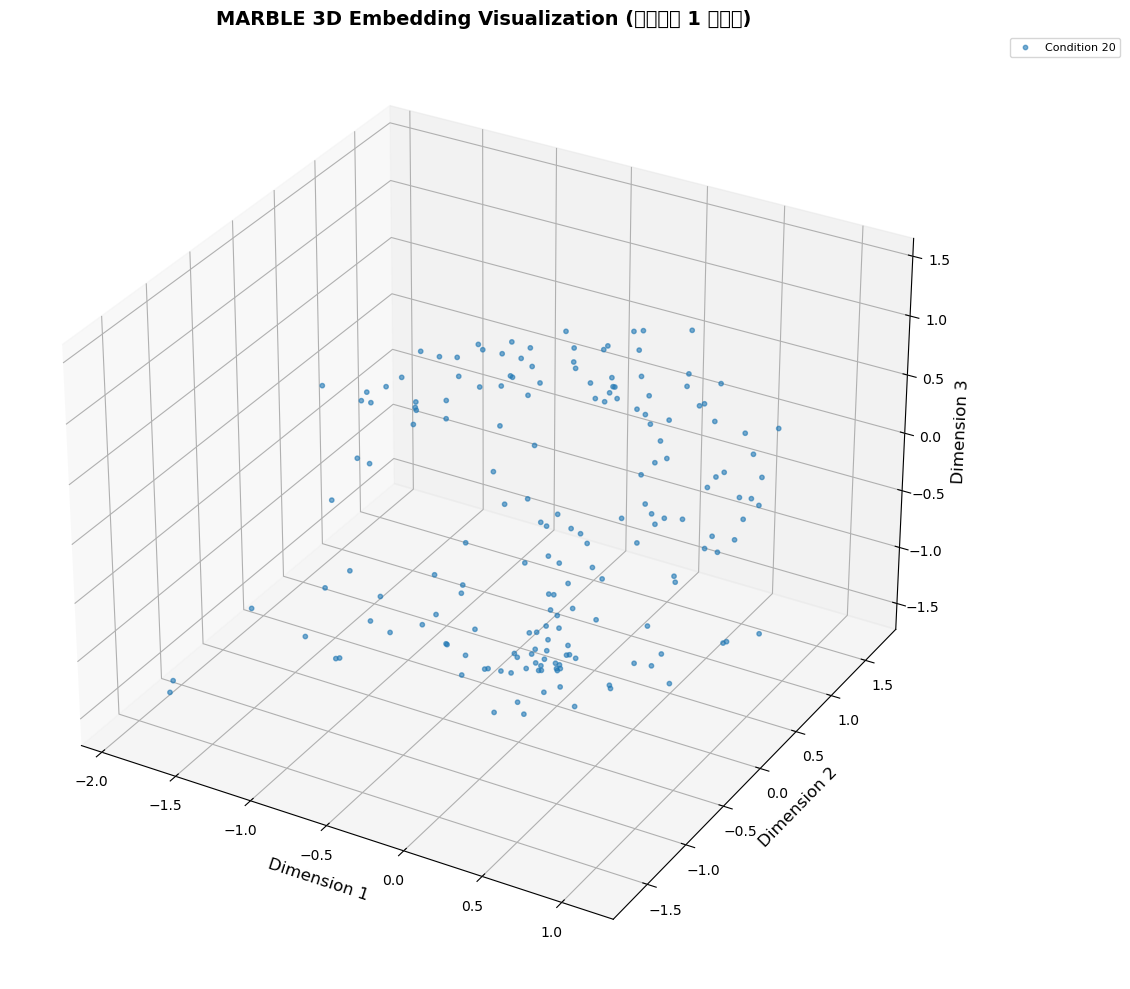

可视化完成!


In [16]:
# 可视化结果（可选）- 随机选择几个类别展示
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random

# 将tensor转换为numpy数组（如果需要）
if hasattr(data.emb, 'cpu'):
    emb_np = data.emb.cpu().numpy()
else:
    emb_np = data.emb.numpy() if hasattr(data.emb, 'numpy') else data.emb

# 设置要展示的类别数量（可以修改这个数字）
n_show = 1  # 随机选择5个类别展示

# 获取所有唯一的condition
unique_conditions = sorted(set(condition_labels_all))
print(f"总共有 {len(unique_conditions)} 个类别")

# 随机选择几个类别
if len(unique_conditions) > n_show:
    selected_conditions = random.sample(unique_conditions, n_show)
    print(f"随机选择了 {n_show} 个类别进行展示: {[conditions[int(c)] for c in selected_conditions]}")
else:
    selected_conditions = unique_conditions
    print(f"类别数量较少，展示所有 {len(unique_conditions)} 个类别")

# 创建3D图形
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 为选中的condition分配颜色
colors = plt.cm.tab10(np.linspace(0, 1, len(selected_conditions)))

# 绘制选中的condition的数据点
for i, cond_idx in enumerate(selected_conditions):
    mask = condition_labels_all == cond_idx
    color = colors[i]
    
    ax.scatter(
        emb_np[mask, 0],
        emb_np[mask, 1],
        emb_np[mask, 2],
        c=[color],
        label=f'Condition {conditions[int(cond_idx)]}',
        s=10,
        alpha=0.6
    )

ax.set_xlabel('Dimension 1', fontsize=12)
ax.set_ylabel('Dimension 2', fontsize=12)
ax.set_zlabel('Dimension 3', fontsize=12)
ax.set_title(f'MARBLE 3D Embedding Visualization (随机选择 {len(selected_conditions)} 个类别)', 
             fontsize=14, fontweight='bold')

# 添加图例
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()
print("可视化完成!")
